# Semana 2

### Generar_Datos


In [ ]:
!pip3 install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 27.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 51.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import random
import string
from datetime import datetime, timedelta
n = 5000


def texto_aleatorio():
    palabras = ["excelente", "malo", "rápido", "lento", "calidad", "precio", "recomendado", "defectuoso"]
    return " ".join(random.choices(palabras, k=random.randint(5, 15)))

def direccion():
    return {
        "calle": random.choice(["Av. Central", "Calle Norte", "Boulevard Sur"]),
        "ciudad": random.choice(["CDMX", "Querétaro", "Monterrey"]),
        "codigo_postal": random.randint(10000, 99999)
    }

def detalles_pedido():
    return {
        "metodo_pago": random.choice(["Tarjeta", "PayPal", "Transferencia"]),
        "envio": random.choice(["Express", "Estándar"])
    }

data = {
    # numéricos
    "precio": np.round(np.random.uniform(50, 2000, n), 2),
    "cantidad": np.random.randint(1, 10, n),
    "descuento": np.round(np.random.uniform(0, 0.3, n), 2),
    "total_venta": np.round(np.random.uniform(100, 5000, n), 2),

    # categóricos
    "categoria_producto": np.random.choice(["Electrónica", "Ropa", "Hogar", "Deportes"], n),
    "metodo_envio": np.random.choice(["Estándar", "Express"], n),

    # estructurados
    "direccion_cliente": [direccion() for _ in range(n)],
    "detalle_pedido": [detalles_pedido() for _ in range(n)],

    # no estructurados
    "comentarios_cliente": [texto_aleatorio() for _ in range(n)],
    "descripcion_producto": [texto_aleatorio() for _ in range(n)]
}

df = pd.DataFrame(data)

# guardar a CSV
df.to_csv("datos_ventas.csv", index=False)

print("Dataset generado con éxito")
print(df.head())


Dataset generado con éxito
    precio  cantidad  descuento  total_venta categoria_producto metodo_envio  \
0  1753.32         6       0.27      1250.96              Hogar      Express   
1   646.46         9       0.08      1229.92              Hogar     Estándar   
2  1578.41         8       0.15       992.39              Hogar      Express   
3  1789.87         7       0.18      1137.15        Electrónica     Estándar   
4  1488.37         7       0.20      2761.69              Hogar      Express   

                                   direccion_cliente  \
0  {'calle': 'Boulevard Sur', 'ciudad': 'Monterre...   
1  {'calle': 'Av. Central', 'ciudad': 'Monterrey'...   
2  {'calle': 'Av. Central', 'ciudad': 'Monterrey'...   
3  {'calle': 'Boulevard Sur', 'ciudad': 'Querétar...   
4  {'calle': 'Boulevard Sur', 'ciudad': 'CDMX', '...   

                                      detalle_pedido  \
0      {'metodo_pago': 'PayPal', 'envio': 'Express'}   
1     {'metodo_pago': 'PayPal', 'envio': 'E

### Cargar a mongo db

In [7]:
from pymongo import MongoClient
import pandas as pd

df = pd.read_csv("datos_ventas.csv")


cliente = MongoClient("mongodb://localhost:27017/")
db = cliente["actividad2"]
coleccion = db["ventas"]


datos = df.to_dict(orient="records")
coleccion.insert_many(datos)

print("Datos insertados correctamente")


datos_mongo = list(coleccion.find())
df_mongo = pd.DataFrame(datos_mongo)

df_mongo.info()
df_mongo.head()
df_mongo.describe()

Datos insertados correctamente
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   5000 non-null   object 
 1   precio                5000 non-null   float64
 2   cantidad              5000 non-null   int64  
 3   descuento             5000 non-null   float64
 4   total_venta           5000 non-null   float64
 5   categoria_producto    5000 non-null   str    
 6   metodo_envio          5000 non-null   str    
 7   direccion_cliente     5000 non-null   str    
 8   detalle_pedido        5000 non-null   str    
 9   comentarios_cliente   5000 non-null   str    
 10  descripcion_producto  5000 non-null   str    
dtypes: float64(3), int64(1), object(1), str(6)
memory usage: 429.8+ KB


,precio,cantidad,descuento,total_venta
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,1019.395140,5.067600,0.150624,2532.804420
std,566.460108,2.581465,0.087307,1405.013276
min,50.060000,1.000000,0.000000,100.780000
25%,525.160000,3.000000,0.070000,1318.700000
50%,1029.290000,5.000000,0.150000,2510.630000
75%,1499.722500,7.000000,0.230000,3771.422500
max,1999.880000,9.000000,0.300000,4998.630000


In [2]:
!pip install seaborn

=== 1. INSPECCIÓN DE ESTRUCTURA ===
Total de registros: 5000
Total de columnas: 11

Tipos de datos detectados:
_id                      object
precio                  float64
cantidad                  int64
descuento               float64
total_venta             float64
categoria_producto          str
metodo_envio                str
direccion_cliente           str
detalle_pedido              str
comentarios_cliente         str
descripcion_producto        str
dtype: object

=== 2. ANÁLISIS DE CALIDAD ===
Valores faltantes por columna:
_id                     0
precio                  0
cantidad                0
descuento               0
total_venta             0
categoria_producto      0
metodo_envio            0
direccion_cliente       0
detalle_pedido          0
comentarios_cliente     0
descripcion_producto    0
dtype: int64

Registros duplicados encontrados: 0

=== 3. DISTRIBUCIÓN Y ESTADÍSTICA DESCRIPTIVA ===
            precio     cantidad    descuento  total_venta
count  5000.000

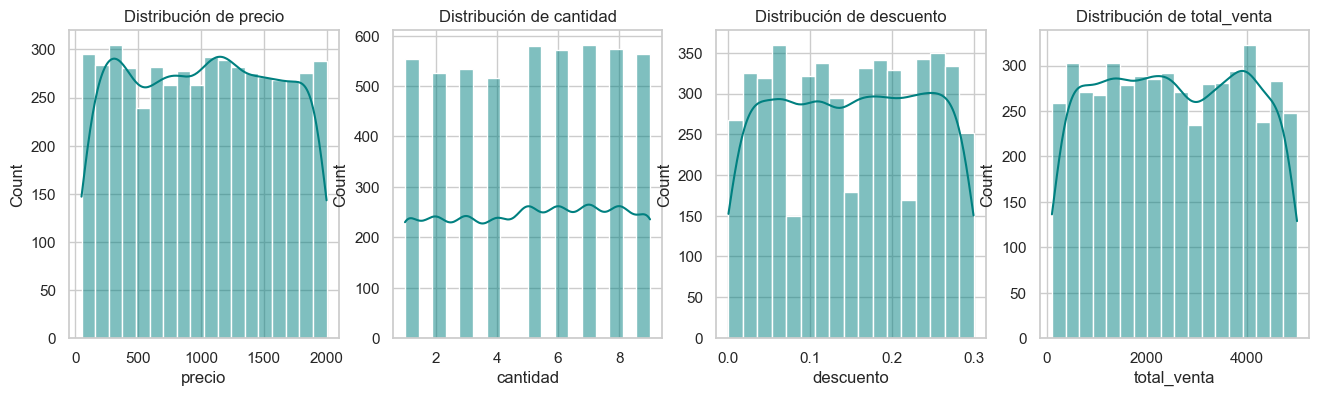

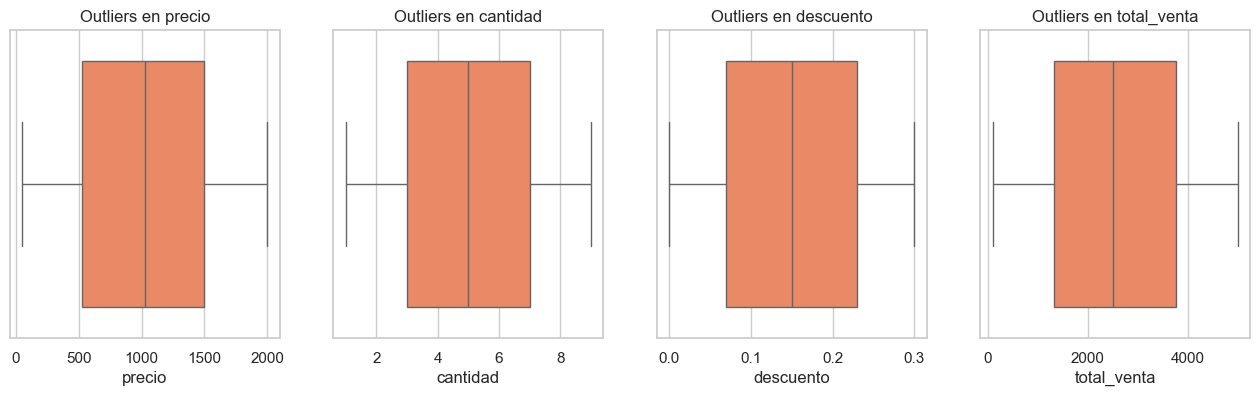


=== 4. RELACIONES ENTRE VARIABLES ===


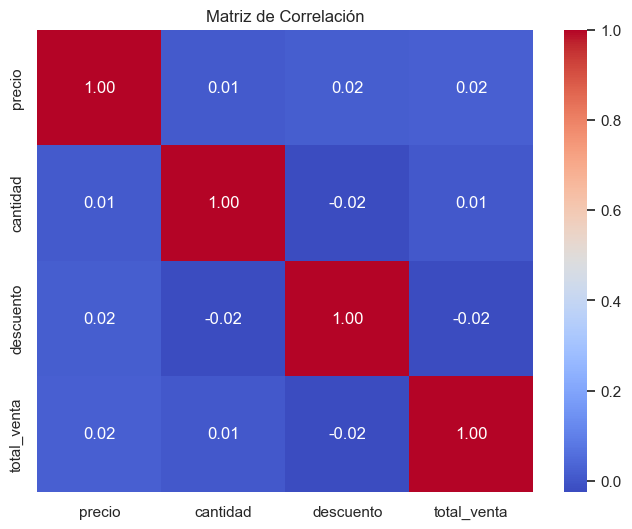

/var/folders/kv/3pgfrlds2p19zwg5r4fbdb3r0000gn/T/ipykernel_70030/2851072966.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='categoria_producto', y='total_venta', data=df_mongo, palette="viridis")


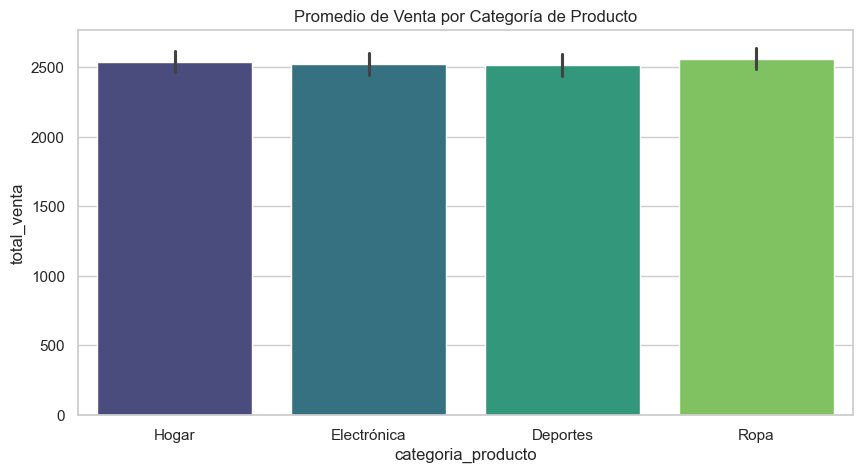

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las gráficas
sns.set_theme(style="whitegrid")

# 1. INSPECCIÓN DE ESTRUCTURA
print("=== 1. INSPECCIÓN DE ESTRUCTURA ===")
print(f"Total de registros: {df_mongo.shape[0]}")
print(f"Total de columnas: {df_mongo.shape[1]}")
print("\nTipos de datos detectados:")
print(df_mongo.dtypes)

# 2. ANÁLISIS DE CALIDAD (Valores Faltantes y Duplicados)
print("\n=== 2. ANÁLISIS DE CALIDAD ===")
null_count = df_mongo.isnull().sum()
print("Valores faltantes por columna:")
print(null_count)

duplicate_count = df_mongo.duplicated().sum()
print(f"\nRegistros duplicados encontrados: {duplicate_count}")

# 3. DISTRIBUCIÓN DE VARIABLES (Numéricas)
print("\n=== 3. DISTRIBUCIÓN Y ESTADÍSTICA DESCRIPTIVA ===")
cols_numericas = ['precio', 'cantidad', 'descuento', 'total_venta']
print(df_mongo[cols_numericas].describe())

# Visualización de Distribución (Histogramas)
plt.figure(figsize=(16, 4))
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 4, i)
    sns.histplot(df_mongo[col], kde=True, color="teal")
    plt.title(f'Distribución de {col}')
plt.show()

# 4. IDENTIFICACIÓN DE VALORES ATÍPICOS (Outliers)
plt.figure(figsize=(16, 4))
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(x=df_mongo[col], color="coral")
    plt.title(f'Outliers en {col}')
plt.show()

# 5. RELACIONES ENTRE VARIABLES
print("\n=== 4. RELACIONES ENTRE VARIABLES ===")
# Correlación entre variables numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df_mongo[cols_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# Relación entre Categoría y Ventas (Boxplot comparativo)
plt.figure(figsize=(10, 5))
sns.barplot(x='categoria_producto', y='total_venta', data=df_mongo, palette="viridis")
plt.title("Promedio de Venta por Categoría de Producto")
plt.show()